In [20]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
%matplotlib inline

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [32]:
## classification
model = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, padding=1),  # [1, 28, 28] -> [4, 28, 28]
    nn.ReLU(),
    nn.MaxPool2d(2),                           # -> [4, 14, 14]

    nn.Conv2d(4, 8, kernel_size=3, padding=1), # -> [8, 14, 14]
    nn.ReLU(),
    nn.MaxPool2d(2),                           # -> [8, 7, 7]

    nn.Flatten(),                              # -> 8 * 7 * 7 = 392
    nn.Linear(392, 10),
    nn.LogSoftmax(dim=1)
)

model.to(device)

Sequential(
  (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=392, out_features=10, bias=True)
  (8): LogSoftmax(dim=1)
)

In [33]:
# num params
print(sum(p.numel() for p in model.parameters()))

4266


In [34]:
# train network with AdamW
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

for epoch in range(10):
    for batch in train_loader:
        X, y = batch
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        print(loss.item())

# test network
with torch.no_grad():
    for batch in test_loader:
        X, y = batch
        X = X.to(device)
        y = y.to(device)
        logits = model(X)
        loss = F.cross_entropy(logits, y)
        print(loss.item())

2.299084186553955
2.2941553592681885
2.2984731197357178
2.299107313156128
2.3004937171936035
2.3128392696380615
2.278488874435425
2.298543691635132
2.276549816131592
2.2755212783813477
2.2809534072875977
2.2642080783843994
2.245436429977417
2.267711639404297
2.2422776222229004
2.2638771533966064
2.2356953620910645
2.22776460647583
2.2364277839660645
2.216585636138916
2.193777084350586
2.2151381969451904
2.178457736968994
2.1930058002471924
2.177415609359741
2.1830124855041504
2.1666295528411865
2.1494789123535156
2.15276837348938
2.1216368675231934
2.1327362060546875
2.1329586505889893
2.1034860610961914
2.0534403324127197
2.0537171363830566
2.05546498298645
2.042783498764038
2.0206360816955566
2.043139696121216
1.9692981243133545
1.96959388256073
1.9936443567276
1.9487665891647339
1.9352591037750244
1.9459776878356934
1.8561314344406128
1.8281363248825073
1.7537481784820557
1.8322471380233765
1.7787715196609497
1.6914576292037964
1.6632628440856934
1.6591516733169556
1.669577121734619

In [36]:
# print accuracy
with torch.no_grad():
    correct = 0
    total = 0
    for batch in test_loader:
        X, y = batch
        X = X.to(device)
        y = y.to(device)
        logits = model(X)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    print(f"Accuracy: {correct / total}")

Accuracy: 0.9807


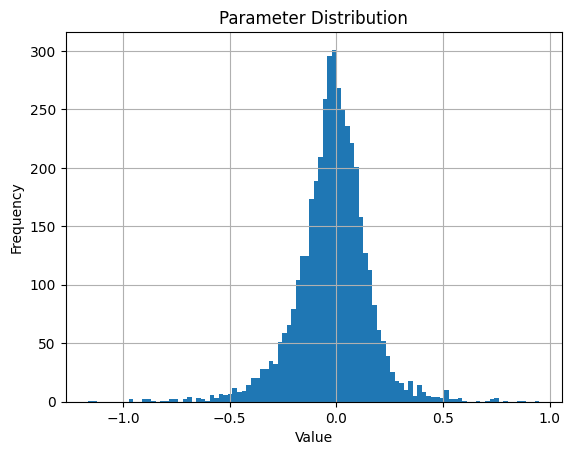

In [38]:
# show distribution of parameters
def plot_param_distribution(model):
    all_params = []

    for name, param in model.named_parameters():
        if param.requires_grad:
            all_params.extend(param.detach().cpu().numpy().flatten())

    plt.hist(all_params, bins=100)
    plt.title("Parameter Distribution")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

plot_param_distribution(model)

In [39]:
for name, param in model.named_parameters():
    if "bias" in name:
        print(f"{name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")


0.bias: mean=0.0014, std=0.0785
3.bias: mean=-0.0932, std=0.1463
7.bias: mean=0.0123, std=0.0771


In [40]:
def quantize_tensor(tensor, num_bits=8):
    qmin = -2**(num_bits - 1)
    qmax = 2**(num_bits - 1) - 1

    max_val = tensor.abs().max().item()
    if max_val == 0:
        scale = 1.0  # avoid division by zero
    else:
        scale = max_val / qmax
    q_tensor = torch.round(tensor / scale).clamp(qmin, qmax).to(torch.int8)
    return q_tensor, scale



In [48]:
def quantize_model(original_model):
    quantized_model = nn.Sequential()  # empty model we'll populate
    scales = {}  # to store quantization scales

    for i, layer in enumerate(original_model):
        new_layer = layer

        if isinstance(layer, (nn.Conv2d, nn.Linear)):
            # Quantize weight
            q_weight, w_scale = quantize_tensor(layer.weight.data)
            new_layer.weight = nn.Parameter(q_weight.to(torch.float32), requires_grad=False)  # keep model compatible

            # Quantize bias if it exists
            if layer.bias is not None:
                q_bias, b_scale = quantize_tensor(layer.bias.data)
                new_layer.bias = nn.Parameter(q_bias.to(torch.float32), requires_grad=False)
            else:
                b_scale = None

            # Store scales
            scales[f"{i}.weight_scale"] = w_scale
            scales[f"{i}.bias_scale"] = b_scale

        quantized_model.add_module(str(i), new_layer)

    return quantized_model, scales

new_model, scales = quantize_model(model)

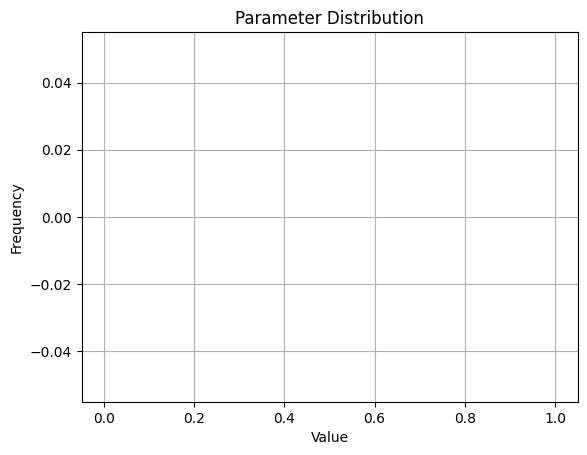

In [49]:
plot_param_distribution(new_model)

In [51]:
with torch.no_grad():
    correct = 0
    total = 0
    for batch in test_loader:
        X, y = batch
        X = X.to(device)
        y = y.to(device)
        logits = new_model(X)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    print(f"Accuracy: {correct / total}")

Accuracy: 0.8601
